In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [4]:
# ===================================================
# LOAD DATASET
# ===================================================

import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Path to dataset files:", path)

# Check files inside dataset folder
print(os.listdir(path))

# Load CSV file
df = pd.read_csv(os.path.join(path, "heart.csv"))

# Display first rows
print(df.head())

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Path to dataset files: /kaggle/input/heart-disease-dataset
['heart.csv']
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Dataset Path:
/kaggle/input/heart-disease-dataset

Files in Dataset Folder:
['heart.csv']

First 5 Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset Shape:
(1025, 14)

Column Names:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

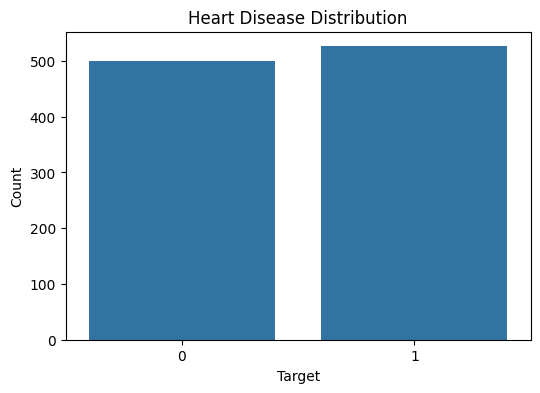

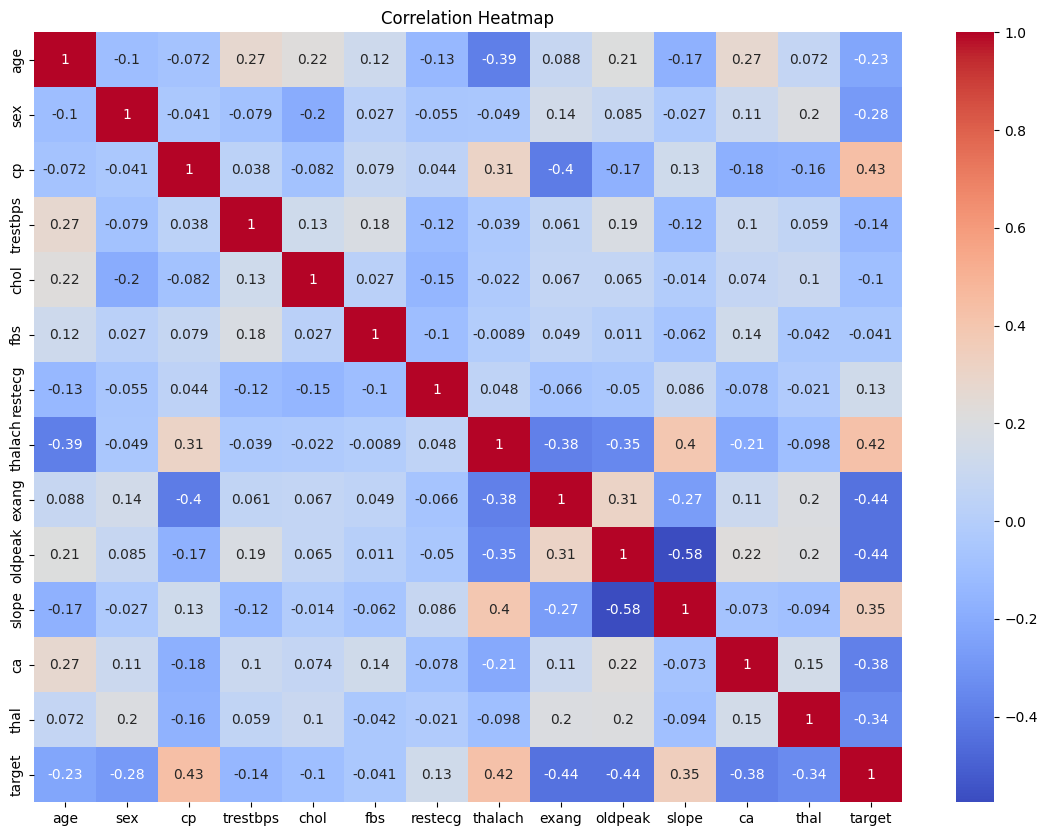

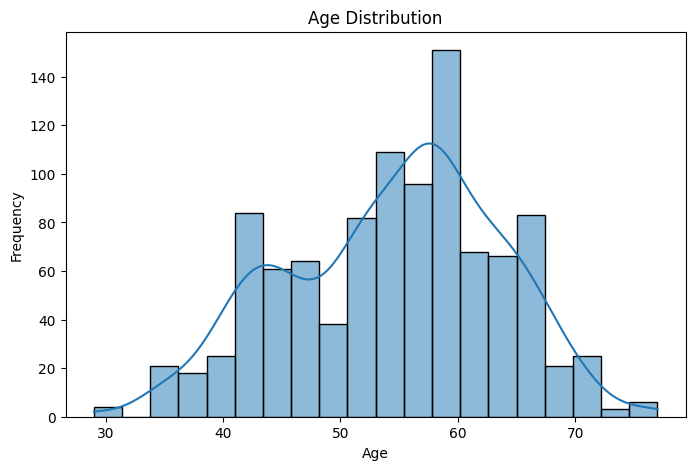


Accuracy Score:
0.7951219512195122

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



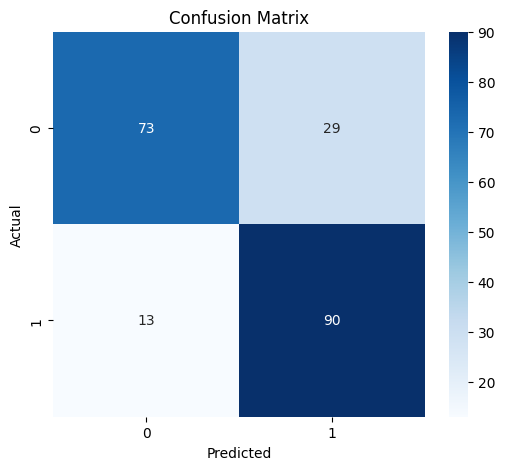

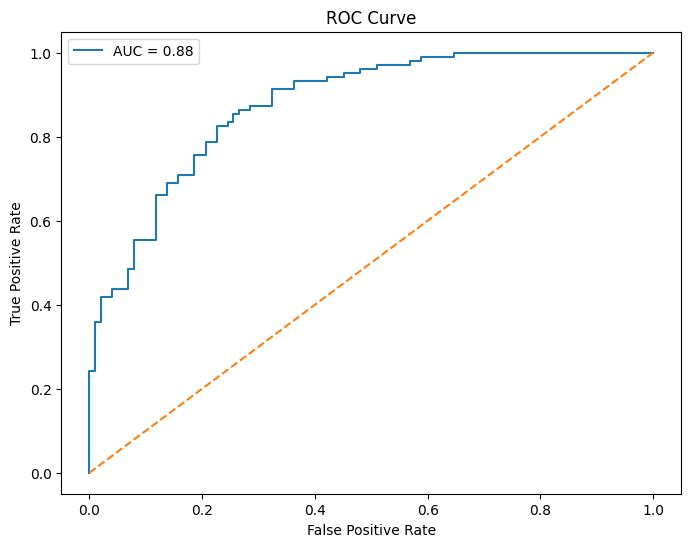


Feature Importance:
     Feature  Coefficient
2         cp     0.847057
10     slope     0.535876
6    restecg     0.262391
7    thalach     0.028880
0        age     0.000642
4       chol    -0.008867
3   trestbps    -0.018159
5        fbs    -0.164529
9    oldpeak    -0.679894
11        ca    -0.814054
8      exang    -0.835868
12      thal    -1.072174
1        sex    -1.714708


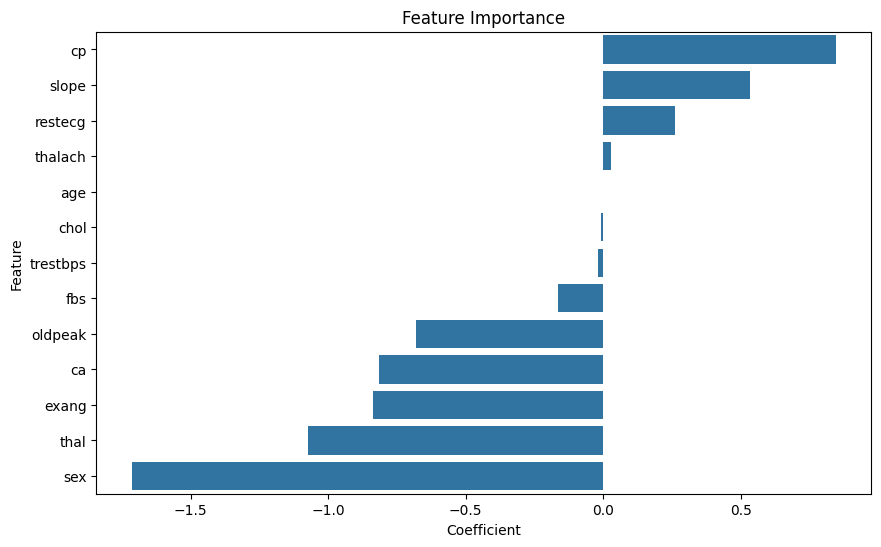


Final Insights:
1. Logistic Regression performed well on the dataset.
2. Medical attributes strongly influence heart disease prediction.
3. ROC-AUC score indicates good model performance.
4. Feature importance identifies major health risk factors.


In [5]:
# ===================================================
# TASK 3 - HEART DISEASE PREDICTION
# ===================================================

# ===================================================
# IMPORT LIBRARIES
# ===================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# ===================================================
# DOWNLOAD & LOAD DATASET
# ===================================================

# Download latest dataset from Kaggle
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Dataset Path:")
print(path)

# Show files inside dataset folder
print("\nFiles in Dataset Folder:")
print(os.listdir(path))

# Load dataset
# Change filename here if needed after checking output
df = pd.read_csv(os.path.join(path, "heart.csv"))

# ===================================================
# BASIC DATASET INFORMATION
# ===================================================

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# ===================================================
# CHECK MISSING VALUES
# ===================================================

print("\nMissing Values:")
print(df.isnull().sum())

# ===================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ===================================================

# Heart Disease Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='target', data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

# Correlation Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

# ===================================================
# FEATURE & TARGET SPLIT
# ===================================================

X = df.drop('target', axis=1)
y = df['target']

# ===================================================
# TRAIN TEST SPLIT
# ===================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ===================================================
# MODEL TRAINING
# ===================================================

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# ===================================================
# PREDICTIONS
# ===================================================

y_pred = model.predict(X_test)

# ===================================================
# MODEL EVALUATION
# ===================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ===================================================
# CONFUSION MATRIX
# ===================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ===================================================
# ROC CURVE
# ===================================================

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# ===================================================
# FEATURE IMPORTANCE
# ===================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print("\nFeature Importance:")
print(importance)

# Feature Importance Visualization
plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

# ===================================================
# FINAL INSIGHTS
# ===================================================

print("\nFinal Insights:")
print("1. Logistic Regression performed well on the dataset.")
print("2. Medical attributes strongly influence heart disease prediction.")
print("3. ROC-AUC score indicates good model performance.")
print("4. Feature importance identifies major health risk factors.")